# load dataset

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df: pd.DataFrame = pd.read_csv("../data/student_performance_data.csv")
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


## cek missing value dan info

In [58]:
missing_value: int = df.isna().sum()
df.info()
print(f"jumlah missing value:\n{missing_value}")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  str    
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  str    
 9   extra_classes          10000 non-null  str    
 10  parent_education       10000 non-null  str    
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  str    
dtypes: float64(8), int64(1), str(5)
memory usage: 1.1 MB
jumlah missin

In [59]:
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


## ganti nama kolom dengan menggunakan bahasa indonesia

In [60]:
df: dict = df.rename(columns={
    'student_id': 'id_siswa',
    'gender': 'jenis_kelamin',
    'study_hours_per_day': 'jam_belajar_per_hari',
    'attendance_percentage': 'presentase_kehadiran',
    'assignment_score': 'nilai_tugas',
    'midterm_score': 'nilai_UTS',
    'final_exam_score': 'nilai_UAS',
    'participation_score': 'nilai_partisipasi',
    'internet_access': 'akses_internet',
    'extra_classes': 'kelas_tambahan',
    'parent_education': 'pendidikan_orang_tua',
    'sleep_hours': 'jam_tidur',
    'overall_score': 'nilai_keseluruhan',
    'grade': 'nilai'
},inplace=False)
df.head()

,id_siswa,jenis_kelamin,jam_belajar_per_hari,presentase_kehadiran,nilai_tugas,nilai_UTS,nilai_UAS,nilai_partisipasi,akses_internet,kelas_tambahan,pendidikan_orang_tua,jam_tidur,nilai_keseluruhan,nilai
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


### encoding kolom dengan tipe data non numerik unutk melihat korelasi

In [61]:
df['akses_internet'] = df['akses_internet'].map({
    'Yes': 1,
    'No' : 0
})

df['jenis_kelamin'] = df['jenis_kelamin'].map({
    'Male' : 1,
    'Female' : 0
})

df['kelas_tambahan'] = df['kelas_tambahan'].map({
    'Yes' : 1,
    'No' : 0
})

df.head()

,id_siswa,jenis_kelamin,jam_belajar_per_hari,presentase_kehadiran,nilai_tugas,nilai_UTS,nilai_UAS,nilai_partisipasi,akses_internet,kelas_tambahan,pendidikan_orang_tua,jam_tidur,nilai_keseluruhan,nilai
0,100000,1,4.54,69.98,36.47,70.70,53.10,17.96,1,0,Master,8.09,52.3480,D
1,100001,0,5.26,84.80,34.25,27.92,87.17,11.29,0,1,Bachelor,4.73,53.9485,D
2,100002,1,8.69,73.76,72.29,70.92,99.61,76.10,0,1,PhD,8.73,82.0375,B
3,100003,1,4.06,45.00,97.63,31.73,88.85,33.55,0,0,Bachelor,8.22,66.4110,C
4,100004,1,8.83,51.13,65.19,78.28,54.23,88.99,0,0,Bachelor,8.59,65.6005,C


In [62]:
df['nilai'] = df['nilai'].map({
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1
},)

df['pendidikan_orang_tua'] = df['pendidikan_orang_tua'].map({
    'PhD' : 'S3',
    'Master': 'S2',
    'Bachelor': 'S1',
    'High School': 'SMA'
}, inplace=True)

df['pendidikan_orang_tua'] = df['pendidikan_orang_tua'].map({
    'S3': 4,
    'S2': 3,
    'S1': 2,
    'SMA': 1
})
df.head()

,id_siswa,jenis_kelamin,jam_belajar_per_hari,presentase_kehadiran,nilai_tugas,nilai_UTS,nilai_UAS,nilai_partisipasi,akses_internet,kelas_tambahan,pendidikan_orang_tua,jam_tidur,nilai_keseluruhan,nilai
0,100000,1,4.54,69.98,36.47,70.70,53.10,17.96,1,0,3,8.09,52.3480,1.0
1,100001,0,5.26,84.80,34.25,27.92,87.17,11.29,0,1,2,4.73,53.9485,1.0
2,100002,1,8.69,73.76,72.29,70.92,99.61,76.10,0,1,4,8.73,82.0375,3.0
3,100003,1,4.06,45.00,97.63,31.73,88.85,33.55,0,0,2,8.22,66.4110,2.0
4,100004,1,8.83,51.13,65.19,78.28,54.23,88.99,0,0,2,8.59,65.6005,2.0


korelasi data

In [68]:
corr = df.corr()
corr

,id_siswa,jenis_kelamin,jam_belajar_per_hari,presentase_kehadiran,nilai_tugas,nilai_UTS,nilai_UAS,nilai_partisipasi,akses_internet,kelas_tambahan,pendidikan_orang_tua,jam_tidur,nilai_keseluruhan,nilai
id_siswa,1.000000,-0.002756,0.011394,0.002863,0.009638,-0.000074,0.006413,-0.004485,-0.002876,-0.001979,0.006117,-0.015926,0.007520,0.006496
jenis_kelamin,-0.002756,1.000000,-0.004755,-0.000101,-0.006321,0.007290,-0.001014,-0.003857,0.005169,-0.008847,0.003969,-0.004085,-0.000307,-0.002321
jam_belajar_per_hari,0.011394,-0.004755,1.000000,-0.014053,-0.011162,0.011053,0.000124,-0.011231,-0.007316,0.007367,0.000645,-0.005728,-0.003651,-0.001383
presentase_kehadiran,0.002863,-0.000101,-0.014053,1.000000,-0.018467,-0.020809,-0.005300,0.006597,-0.012296,0.001015,-0.013131,-0.008273,0.148781,0.133164
nilai_tugas,0.009638,-0.006321,-0.011162,-0.018467,1.000000,0.011557,0.007125,-0.011734,-0.007939,0.009414,-0.000015,-0.002974,0.396961,0.348972
nilai_UTS,-0.000074,0.007290,0.011053,-0.020809,0.011557,1.000000,-0.003691,-0.000266,0.024200,0.017967,0.004815,0.016816,0.528902,0.478320
nilai_UAS,0.006413,-0.001014,0.000124,-0.005300,0.007125,-0.003691,1.000000,-0.008686,0.032597,-0.011188,-0.006488,-0.007952,0.689326,0.632948
nilai_partisipasi,-0.004485,-0.003857,-0.011231,0.006597,-0.011734,-0.000266,-0.008686,1.000000,-0.004391,0.002217,-0.004016,-0.005550,0.244067,0.213481
akses_internet,-0.002876,0.005169,-0.007316,-0.012296,-0.007939,0.024200,0.032597,-0.004391,1.000000,-0.034220,-0.008282,-0.005996,0.029078,0.022975
kelas_tambahan,-0.001979,-0.008847,0.007367,0.001015,0.009414,0.017967,-0.011188,0.002217,-0.034220,1.000000,0.014346,-0.005973,0.006219,0.002627


## visualisasi data

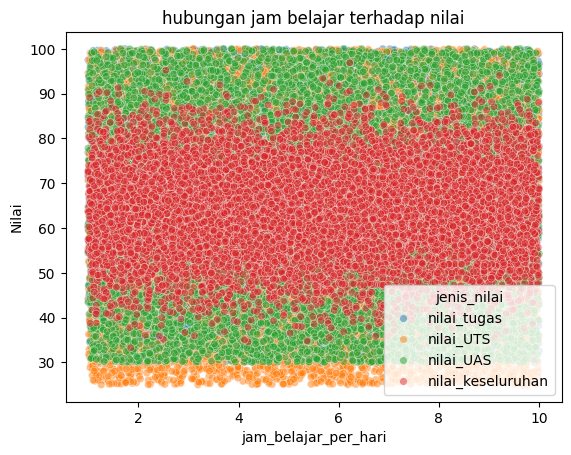

In [74]:
df_melt = df.melt(
    id_vars = ['jam_belajar_per_hari', 'presentase_kehadiran'],
    value_vars= ['nilai_tugas', 'nilai_UTS', 'nilai_UAS', 'nilai_keseluruhan'],
    var_name='jenis_nilai',
    value_name='Nilai'
)
sns.scatterplot(
    x='jam_belajar_per_hari',
    y='Nilai',
    hue='jenis_nilai',
    data=df_melt,
    alpha=0.5,
    s=30
)

plt.title("hubungan jam belajar terhadap nilai")
plt.show()

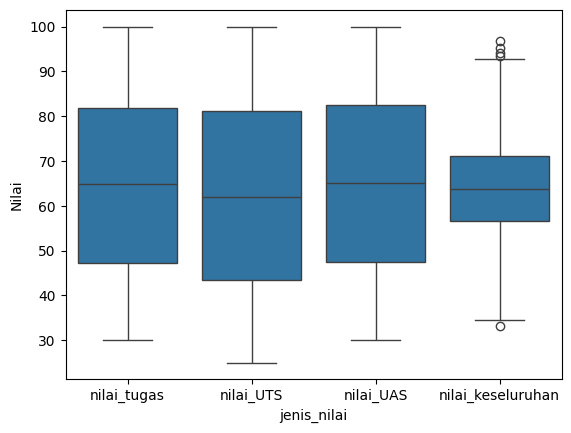

In [81]:
sns.boxplot(
    x='jenis_nilai',
    y='Nilai',
    data=df_melt
)
plt.show()

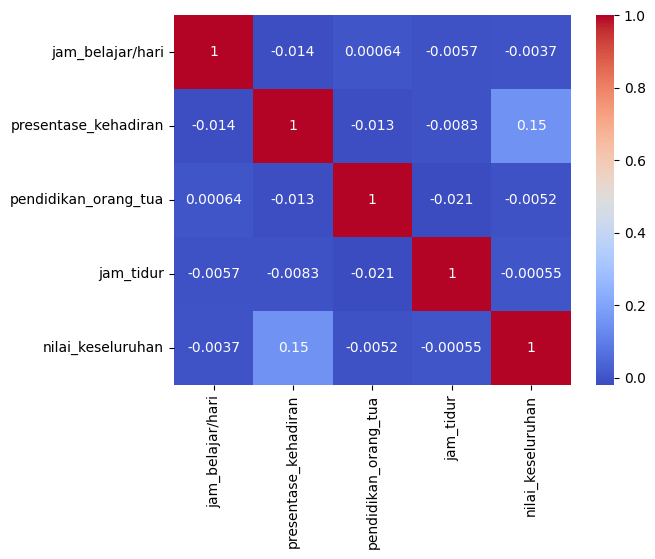

In [9]:
cor = df[['jam_belajar/hari','presentase_kehadiran','pendidikan_orang_tua','jam_tidur', 'nilai_keseluruhan']].corr()
sns.heatmap(cor, annot=True, cmap='coolwarm')
plt.show()